# **Étape 1 - Crée l'environnement conda avec Python 3.11**

In [44]:
import torch
import torchvision
import sklearn
import matplotlib

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Sklearn     : {sklearn.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"")
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"Nombre de GPU   : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU détecté     : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM totale     : {props.total_memory / 1e9:.1f} GB")
    print(f"\nEnvironnement GPU prêt !")
else:
    print("CUDA non disponible")

PyTorch     : 2.5.1+cu121
Torchvision : 0.20.1+cu121
Sklearn     : 1.8.0
Matplotlib  : 3.10.8

CUDA disponible : True
Nombre de GPU   : 1
GPU détecté     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM totale     : 6.4 GB

Environnement GPU prêt !


# **Chargement et visualisation du dataset :**

In [45]:
import os

data_dir = "D:\COURS\GIS AI\Trees in Satellite Imagery\Data" 

# Vérification structure
for classe in os.listdir(data_dir):
    n = len(os.listdir(os.path.join(data_dir, classe)))
    print(f"{classe} : {n} images")

NoTrees : 5200 images
Trees : 5200 images


In [46]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

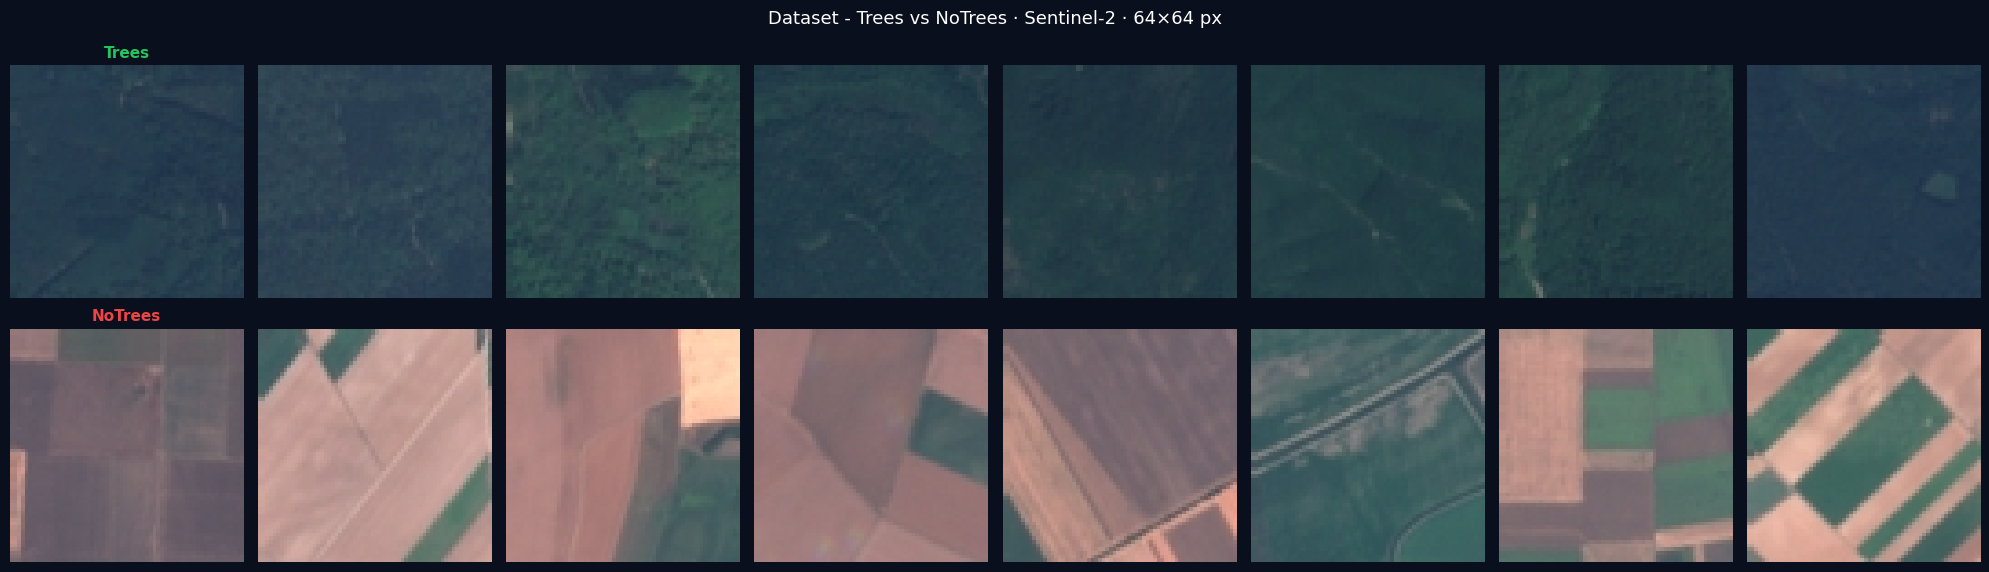

✅ Visualisation sauvegardée !


In [47]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.patch.set_facecolor('#0a0f1e')

classes = ['Trees', 'NoTrees']
colors  = ['#22c55e', '#ef4444']

for row, (classe, color) in enumerate(zip(classes, colors)):
    class_dir = os.path.join(data_dir, classe)
    images    = os.listdir(class_dir)[:8]

    for col, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(class_dir, img_name))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(classe, color=color,
                                     fontsize=11, fontweight='bold')

plt.suptitle('Dataset - Trees vs NoTrees · Sentinel-2 · 64×64 px',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('dataset_preview.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0f1e')
plt.show()
print("✅ Visualisation sauvegardée !")

In [48]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

In [49]:

# Transformations
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [50]:

# Chargement
dataset_full = datasets.ImageFolder(root=data_dir,
                                    transform=transform_train)
print(f"Classes : {dataset_full.classes}")
print(f"Total   : {len(dataset_full)} images")

# Split 70% / 15% / 15%
n_total = len(dataset_full)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset_full, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Appliquer transform_test sur val et test
val_set.dataset.transform  = transform_test
test_set.dataset.transform = transform_test

# DataLoaders
loader_train = DataLoader(train_set, batch_size=32,
                          shuffle=True,  num_workers=0)
loader_val   = DataLoader(val_set,   batch_size=32,
                          shuffle=False, num_workers=0)
loader_test  = DataLoader(test_set,  batch_size=32,
                          shuffle=False, num_workers=0)



Classes : ['NoTrees', 'Trees']
Total   : 10400 images


In [51]:
print(f"\nTrain : {len(train_set)} images")
print(f"Val   : {len(val_set)} images")
print(f"Test  : {len(test_set)} images")
print(f"\nDataLoaders prêts !")


Train : 7279 images
Val   : 1560 images
Test  : 1561 images

DataLoaders prêts !


# Modèle : ResNet

In [52]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

In [53]:

model_resnet = models.resnet18(weights='IMAGENET1K_V1')


In [54]:

# Geler toutes les couches
for param in model_resnet.parameters():
    param.requires_grad = False

In [55]:
# Remplacer fc
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 2)   # 512 = in_features de ResNet18
)


In [56]:
# Fine-tuning partiel - dégeler layer3 et layer4
for param in model_resnet.layer3.parameters():
    param.requires_grad = True
for param in model_resnet.layer4.parameters():
    param.requires_grad = True

In [57]:
# Envoyer sur GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)

In [58]:
# Optimiseur avec learning rates différenciés
optimizer_resnet = optim.Adam([
    {'params': model_resnet.layer3.parameters(), 'lr': 1e-4},
    {'params': model_resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': model_resnet.fc.parameters(),     'lr': 1e-3},
])

scheduler_resnet = optim.lr_scheduler.StepLR(
    optimizer_resnet, step_size=5, gamma=0.5
)

In [59]:
total     = sum(p.numel() for p in model_resnet.parameters())
trainable = sum(p.numel() for p in model_resnet.parameters()
                if p.requires_grad)

print(f"Paramètres totaux    : {total:,}")
print(f"Paramètres entraînés : {trainable:,}")

Paramètres totaux    : 11,177,538
Paramètres entraînés : 10,494,466


In [ ]:
# Fonctions d'entraînement et d'évaluation
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs    = model(imgs)
            total_loss += criterion(outputs, labels).item()
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [62]:
# ENTRAÎNEMENT - ResNet18 Fine-tuning

N_EPOCHS = 20
history_resnet = {"train_loss": [], "val_loss": [],
                  "train_acc":  [], "val_acc":  []}
best_val   = 0
best_epoch = 0

print("Entraînement ResNet18 Fine-tuning...\n")
for epoch in range(N_EPOCHS):
    tr_loss, tr_acc = train_epoch(model_resnet, loader_train,
                                  optimizer_resnet, criterion)
    vl_loss, vl_acc = eval_epoch(model_resnet, loader_val, criterion)
    scheduler_resnet.step()

    history_resnet["train_loss"].append(tr_loss)
    history_resnet["val_loss"].append(vl_loss)
    history_resnet["train_acc"].append(tr_acc)
    history_resnet["val_acc"].append(vl_acc)

    if vl_acc > best_val:
        best_val   = vl_acc
        best_epoch = epoch + 1
        torch.save(model_resnet.state_dict(), "best_resnet.pth")

    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"Train Acc: {tr_acc:.4f} | "
          f"Val Acc: {vl_acc:.4f}"
          + (" ← best" if vl_acc == best_val else ""))

print(f"\nTerminé ! Meilleure Val Accuracy : {best_val:.4f} (epoch {best_epoch})")

Entraînement ResNet18 Fine-tuning...



NameError: name 'criterion' is not defined